In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('train.csv')
df.loc[:,'Sex'] = df.loc[:,'Sex'].map({'male': 0, 'female': 1})
df = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Embarked'])
df.head(3)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
0,0,3,0,22.0,1,0,7.2500
1,1,1,1,38.0,1,0,71.2833
2,1,3,1,26.0,0,0,7.9250


In [3]:
df.isna().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
dtype: int64

In [4]:
df = df.dropna()

In [5]:
df.groupby('Survived')['Pclass'].count()
# выбираю в качестве метрики roc-auc т.к. данные несбалансированы и метрика не зависит от порога классификации

Survived
0    424
1    290
Name: Pclass, dtype: int64

In [6]:
y = df['Survived']
X = df.drop(columns=['Survived'])
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=2026, test_size=0.25, stratify=y)

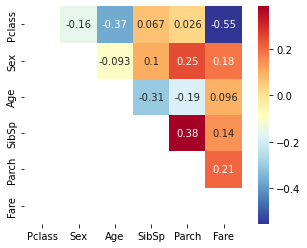

In [7]:
corrs = X.corr()
upper_tri = corrs.where(np.triu(np.ones(corrs.shape), k=1).astype(bool))
sns.heatmap(upper_tri, cmap="RdYlBu_r", square=True, annot=True);
# выраженных корелляций нет, оставляю выбранные признаки

In [8]:
dummy_clf = DummyClassifier(strategy="most_frequent")
dummy_clf.fit(X_train, y_train);
y_pred_dummy = dummy_clf.predict(X_test)

In [9]:
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train);
y_pred_log_reg = log_reg.predict(X_test)

In [10]:
# обучение на отмасштабированных данных
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

log_reg_scaled = LogisticRegression()
log_reg_scaled.fit(X_train_scaled, y_train);
y_pred_log_reg_scaled = log_reg_scaled.predict(X_test_scaled)

In [11]:
print(f'ROC AUC for Dummy Classificator: {roc_auc_score(y_test, y_pred_dummy)}')
print(f'ROC AUC for Logistic regression: {roc_auc_score(y_test, y_pred_log_reg)}')
print(f'ROC AUC for Logistic regression (scaled data): {roc_auc_score(y_test, y_pred_log_reg_scaled)}')

ROC AUC for Dummy Classificator: 0.5
ROC AUC for Logistic regression: 0.8226932023778754
ROC AUC for Logistic regression (scaled data): 0.8274101835099509
